In [74]:
# import library
import pandas as pd # untuk baca dan olah data
import matplotlib.pyplot as plt # untuk visualisasi data
import matplotlib.ticker as ticker # untuk format angka pada visualisasi

In [ ]:
# membaca dataset
data = pd.read_csv("data/ecommerce_10000.csv")
data.head()

,OrderID,Product,Category,Brand,Platform,City,Price,Quantity,TotalAmount,Rating,Reviews,OrderDate
0,ORD100000,Samsung Galaxy A14,Electronics,Samsung,Souq,Cairo,16284.02,1,16284.02,1.39,1684,2024-11-11
1,ORD100001,Nike Air Max,Fashion,Nike,Jumia,Alexandria,6645.20,2,13290.40,2.56,3604,2024-06-22
2,ORD100002,Bluetooth Headset,Accessories,JBL,Jumia,Casablanca,8882.92,3,26648.76,4.98,1257,2024-05-27
3,ORD100003,HP Pavilion Laptop,Computers,HP,Souq,Dubai,3665.44,1,3665.44,1.44,662,2024-07-25
4,ORD100004,iPhone 13,Electronics,Apple,Souq,Casablanca,5210.37,2,10420.74,3.73,2424,2024-02-19


In [90]:
# menampilkan informasi dataset
print("Informasi Jumlah Kolom dan Baris")
print("--------------------------------")
print("Jumlah Baris :", data.shape [0])
print("Jumlah Kolom : ", data.shape [1], "\n")

print("Informasi Tipe Data Setiap Kolom")
print("-----------------------------------")
data.info(), "\n"

print("Ringkasan Statistik Dataset Untuk Kolom Numerik")
print("------------------------------------------------")
data.describe()


Informasi Jumlah Kolom dan Baris
--------------------------------
Jumlah Baris : 10000
Jumlah Kolom :  14 

Informasi Tipe Data Setiap Kolom
-----------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   OrderID      10000 non-null  object        
 1   Product      10000 non-null  object        
 2   Category     10000 non-null  object        
 3   Brand        10000 non-null  object        
 4   Platform     10000 non-null  object        
 5   City         10000 non-null  object        
 6   Price        10000 non-null  float64       
 7   Quantity     10000 non-null  int64         
 8   TotalAmount  10000 non-null  float64       
 9   Rating       10000 non-null  float64       
 10  Reviews      10000 non-null  int64         
 11  OrderDate    10000 non-null  datetime64[ns]
 12  Bulan        10000 non-n

,Price,Quantity,TotalAmount,Rating,Reviews,OrderDate,JumlahBulan
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000,10000.000000
mean,10027.986331,3.006200,30199.572439,3.005592,2520.072200,2024-06-28 18:28:39.360000,6.431800
min,105.590000,1.000000,113.550000,1.000000,0.000000,2024-01-01 00:00:00,1.000000
25%,4999.862500,2.000000,11066.910000,2.010000,1275.000000,2024-03-30 00:00:00,3.000000
50%,10063.600000,3.000000,23671.630000,3.005000,2537.500000,2024-06-29 00:00:00,6.000000
75%,14938.430000,4.000000,44648.580000,4.000000,3767.000000,2024-09-28 00:00:00,9.000000
max,19999.340000,5.000000,99993.800000,5.000000,5000.000000,2024-12-26 00:00:00,12.000000
std,5728.261196,1.415472,23861.789828,1.154845,1443.849734,NaN,3.423379


In [63]:
# mengubah type data untuk kolom OrderDate menjadi date
data["OrderDate"] = pd.to_datetime(data["OrderDate"], dayfirst=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   OrderID      10000 non-null  object        
 1   Product      10000 non-null  object        
 2   Category     10000 non-null  object        
 3   Brand        10000 non-null  object        
 4   Platform     10000 non-null  object        
 5   City         10000 non-null  object        
 6   Price        10000 non-null  float64       
 7   Quantity     10000 non-null  int64         
 8   TotalAmount  10000 non-null  float64       
 9   Rating       10000 non-null  float64       
 10  Reviews      10000 non-null  int64         
 11  OrderDate    10000 non-null  datetime64[ns]
 12  Bulan        10000 non-null  period[M]     
 13  JumlahBulan  10000 non-null  int32         
dtypes: datetime64[ns](1), float64(3), int32(1), int64(2), object(6), period[M](1)
memory usage: 1.0+ MB


In [39]:
# mengecek jumlah kolom yang tidak memiliki nilai
data.isna().sum()

OrderID        0
Product        0
Category       0
Brand          0
Platform       0
City           0
Price          0
Quantity       0
TotalAmount    0
Rating         0
Reviews        0
OrderDate      0
Bulan          0
dtype: int64

In [40]:
# mengecek apakah ada duplikasi data
data.duplicated().sum()

0

In [ ]:
# Mengambil angka bulan (1–12) dari OrderDate 
data["JumlahBulan"] = data["OrderDate"].dt.month
list_bulan = {
    1 : "Januari",
    2 : "Februari",
    3 : "Maret",
    4 : "April",
    5 : "Mei",
    6 : "Juni",
    7 : "Juli",
    8 : "Agustus",
    9 : "September",
    10 : "Oktober",
    11 : "November",
    12 : "Desember"
}

# Mengubah angka bulan pada kolom JumlahBulan menjadi nama bulan
data["Bulan"] = data["JumlahBulan"].map(list_bulan)

In [66]:
# menghitung total pendapatan per bulan
pendapatan_per_bulan = data.groupby(["JumlahBulan", "Bulan"])["TotalAmount"].sum().reset_index().sort_values("JumlahBulan")
pendapatan_per_bulan[["Bulan", "TotalAmount"]]

,Bulan,TotalAmount
0,Januari,26425904.77
1,Februari,23199060.32
2,Maret,25599416.15
3,April,24950410.65
4,Mei,26286508.96
5,Juni,23649020.33
6,Juli,26801658.28
7,Agustus,25264031.98
8,September,26498388.36
9,Oktober,25713673.72


In [104]:
# mengambil nilai minimum dan maksimum untuk sumbu y pada visualisasi
y_min = pendapatan_per_bulan["TotalAmount"].min()
y_max = pendapatan_per_bulan["TotalAmount"].max()

# menambahkan selisih nilai sebesar 5% dari selisih y_max dan y_min
selisih = (y_max - y_min) * 0.05

# membuat format angka untuk sumbu y
formatter = ticker.FuncFormatter(
    lambda x, _: f"{int(x):,}".replace(",", ".")
)

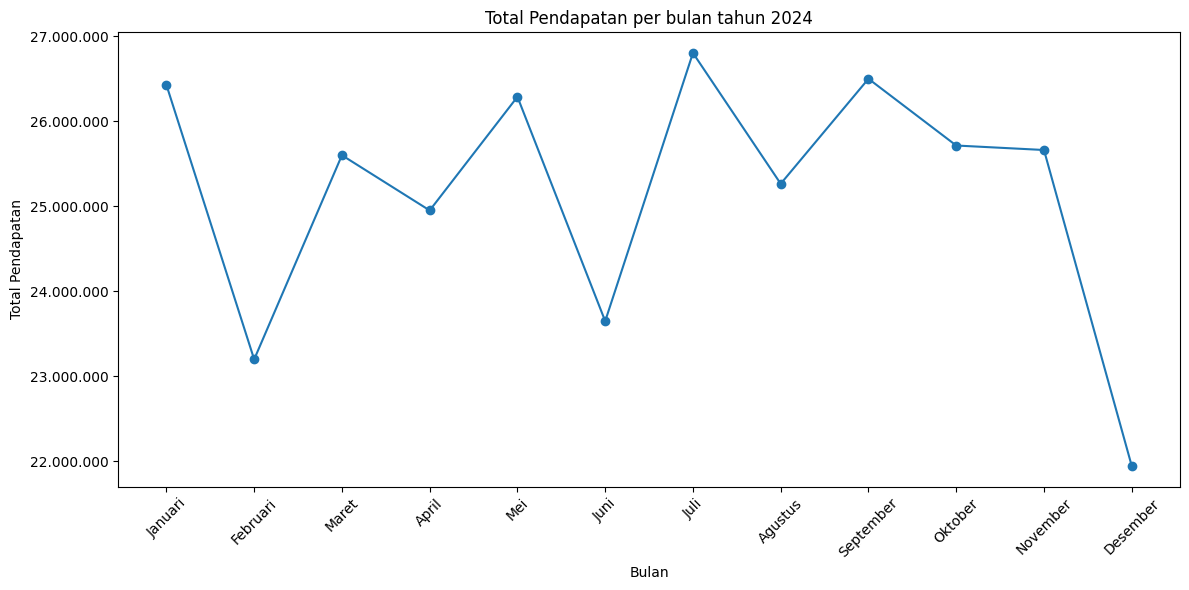

In [105]:
# visualisasi total pendapatan per bulan menggunakan line chart
plt.figure(figsize=(12,6))
plt.plot(pendapatan_per_bulan["Bulan"], pendapatan_per_bulan["TotalAmount"], marker="o")

plt.xlabel("Bulan")
plt.ylabel("Total Pendapatan")
plt.title("Total Pendapatan per bulan tahun 2024")

plt.ylim(y_min - selisih, y_max + selisih)
plt.gca().yaxis.set_major_formatter(formatter)
plt.ylim(y_min - selisih, y_max + selisih)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



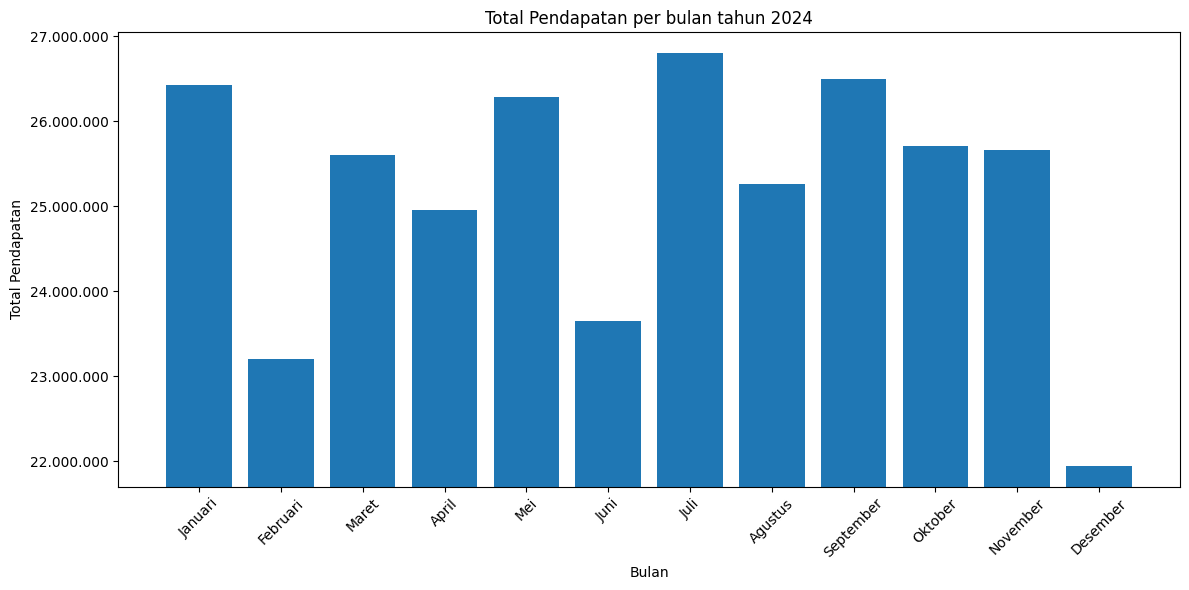

In [106]:
# visualisasi total pendapatan per bulan menggunakan Bar Chart
plt.figure(figsize=(12,6))
plt.bar(pendapatan_per_bulan["Bulan"], pendapatan_per_bulan["TotalAmount"])
plt.xlabel("Bulan")
plt.ylabel("Total Pendapatan")
plt.title("Total Pendapatan per bulan tahun 2024")

plt.ylim(y_min - selisih, y_max + selisih)
plt.gca().yaxis.set_major_formatter(formatter)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

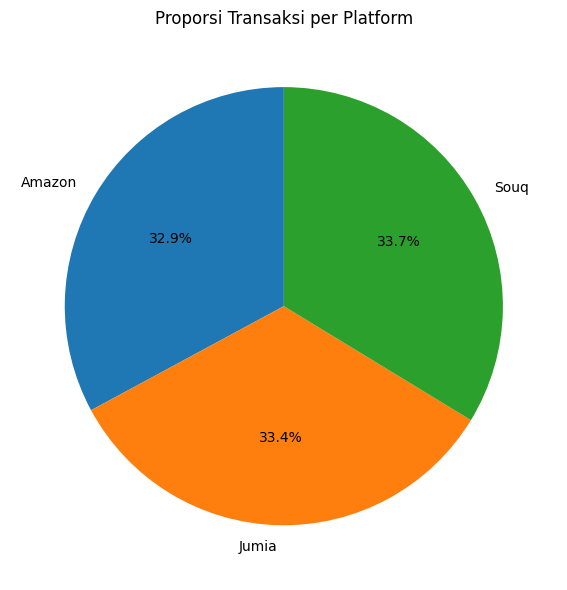

In [93]:
# visualisasi proporsi kontribusi platform berdasarkan jumlah transaksi
transaksi_per_platform = data.groupby("Platform")["OrderID"].count().reset_index()

# visualisasi pie chart
plt.figure(figsize=(6,6))
plt.pie(
    transaksi_per_platform["OrderID"],
    labels=transaksi_per_platform["Platform"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Proporsi Transaksi per Platform")
plt.tight_layout()
plt.show()

In [ ]:
# menghitung total pendapatan per kota
pendapatan_per_kota = data.groupby("City")["TotalAmount"].sum().reset_index()
pendapatan_per_kota



,City,TotalAmount
0,Alexandria,48844458.99
1,Cairo,52522076.73
2,Casablanca,52382993.51
3,Dubai,49177483.79
4,Giza,48704335.49
5,Riyadh,50364375.88


In [102]:
# mengambil nilai minimum dan maksimum untuk sumbu y pada visualisasi
y_min = pendapatan_per_kota["TotalAmount"].min()
y_max = pendapatan_per_kota["TotalAmount"].max()

# menambahkan selisih nilai sebesar 5% dari selisih y_max dan y_min
selisih_nilai = (y_max - y_min) * 0.05

# membuat format angka untuk sumbu y
formatter = ticker.FuncFormatter(
    lambda x, _: f"{int(x):,}".replace(",", ".")
)

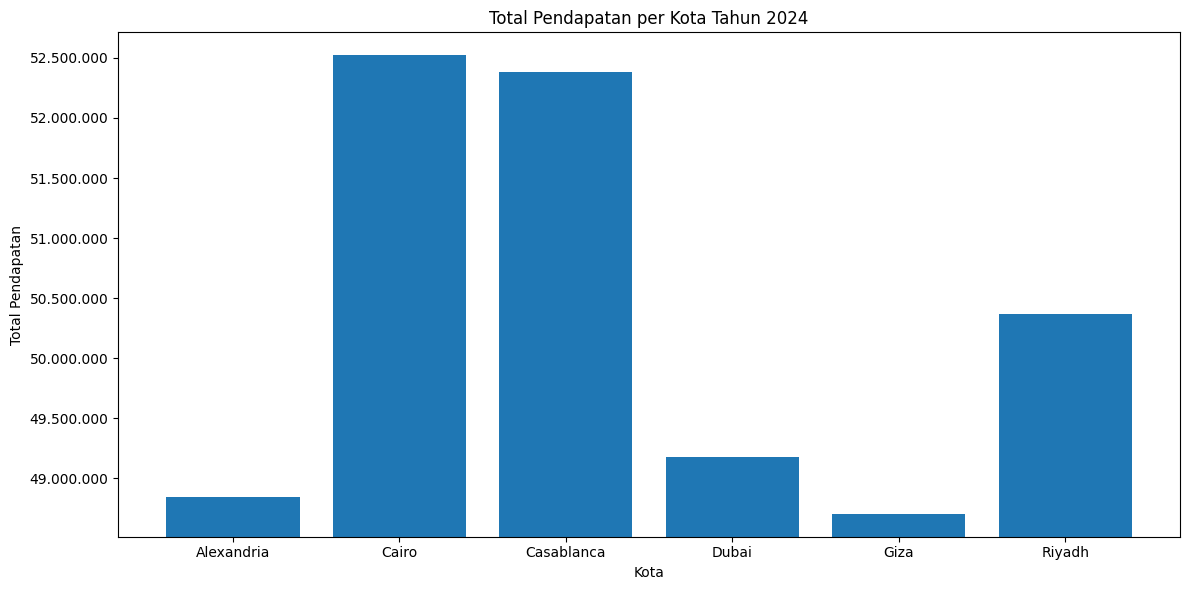

In [ ]:
# visualisasi total pendapatan per kota menggunakan Bar Chart
plt.figure(figsize=(12,6))
plt.bar(pendapatan_per_kota["City"], pendapatan_per_kota["TotalAmount"])

plt.xlabel("Kota")
plt.ylabel("Total Pendapatan")
plt.title("Total Pendapatan per Kota Tahun 2024")

plt.ylim(y_min - selisih_nilai, y_max + selisih_nilai)
plt.gca().yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()